In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("C:/Datasets/ca11-03homes.xls", "Sheet1")
df

,Obs,Price,SqFt,BedRooms,Baths,Garage,Zip
0,1,52900,932,1,1.0,0,4
1,2,61500,780,3,1.0,0,5
2,3,62000,1500,3,1.0,0,9
3,4,62900,760,2,1.0,0,4
4,5,64900,900,2,1.0,0,4
...,...,...,...,...,...,...,...
499,500,490000,3900,4,3.5,3,5
500,501,535000,3331,5,3.5,3,6
501,502,549000,3615,4,4.5,3,5
502,503,625000,4840,4,4.0,3,6


In [3]:
df.isnull().sum()

Obs         0
Price       0
SqFt        0
BedRooms    0
Baths       0
Garage      0
Zip         0
dtype: int64

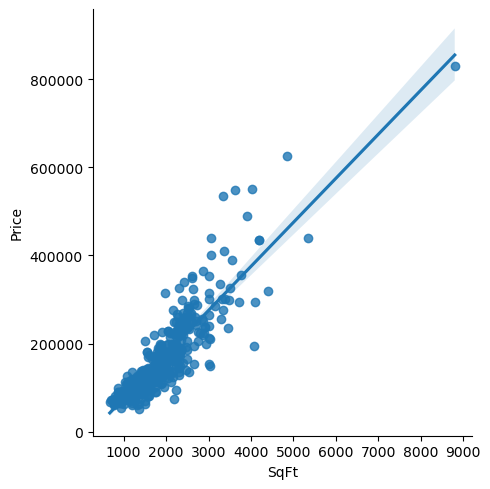

In [9]:
import seaborn as sns
sns.lmplot(data = df, x = "SqFt", y = "Price")

<Axes: xlabel='BedRooms', ylabel='Price'>

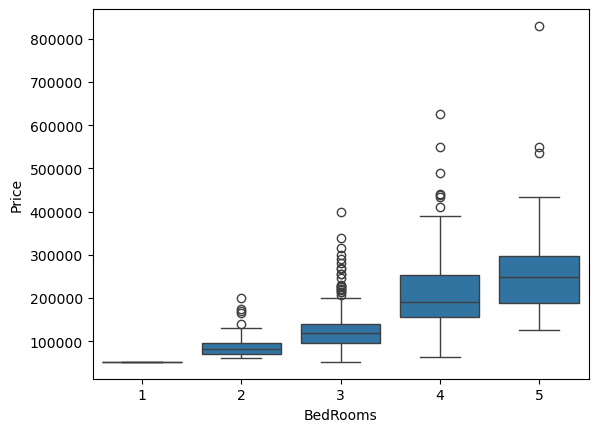

In [10]:
sns.boxplot(data = df, x = "BedRooms", y = "Price")

<Axes: xlabel='Baths', ylabel='Price'>

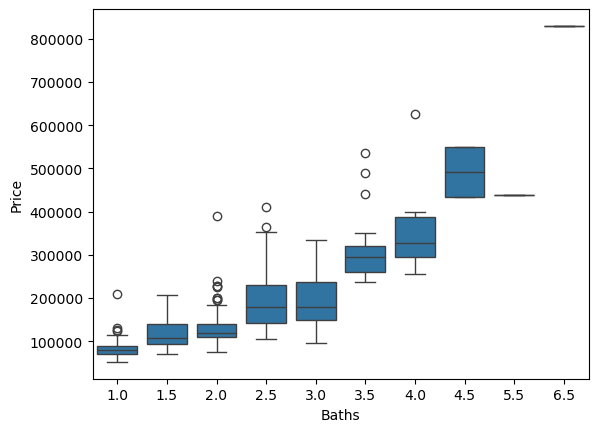

In [11]:
sns.boxplot(data = df, x = "Baths", y = "Price")

In [14]:
q3 = df["Price"].quantile(0.75)
q3

np.float64(184900.0)

In [15]:
q1 = df["Price"].quantile(0.25)
q1

np.float64(104900.0)

In [16]:
iqr = q3 - q1
iqr

np.float64(80000.0)

In [17]:
ul = q3 + (1.5 * iqr)
ll = q1 - (1.5 * iqr)
print(ll, ul)

-15100.0 304900.0


In [20]:
import numpy as np
upper = np.where(df["Price"] >= ul)
lower = np.where(df["Price"] <= ll)

In [21]:
df.drop(upper[0], inplace = True)
df.drop(lower[0], inplace = True)

In [22]:
x = df.iloc[ : , 2 : 5].values
x

array([[9.320e+02, 1.000e+00, 1.000e+00],
       [7.800e+02, 3.000e+00, 1.000e+00],
       [1.500e+03, 3.000e+00, 1.000e+00],
       ...,
       [3.714e+03, 4.000e+00, 4.000e+00],
       [3.492e+03, 4.000e+00, 4.000e+00],
       [3.318e+03, 4.000e+00, 2.500e+00]], shape=(478, 3))

In [23]:
y = df.iloc[ : , 1].values
y

array([ 52900,  61500,  62000,  62900,  64900,  64900,  65000,  65000,
        67900,  68900,  69500,  69900,  69900,  69900,  71000,  72500,
        72900,  73500,  75000,  76900,  77000,  77500,  77900,  78900,
        79000,  79900,  79900,  79900,  79900,  84900,  87900,  89000,
        89900,  89900,  89900,  94900,  95000, 129900, 139000, 139900,
       169900, 172000, 184900,  52000,  59900,  59900,  69900,  72000,
        72500,  72900,  73500,  73900,  73900,  78900,  79900,  79900,
        81500,  82900,  84500,  84900,  84900,  84900,  84900,  86000,
        86000,  87500,  87900,  88000,  88500,  89900,  89900,  89900,
        89900,  89900,  91600,  92800,  92900,  93500,  94500,  94900,
        94900,  94900,  95000,  95000,  96500,  99500, 100900, 101500,
       104000, 104900, 105000, 109900, 112500, 113000, 114900, 119900,
       122900, 129900, 134900, 144900, 150000, 159500, 159900,  62000,
        63900,  65000,  72900,  72900,  72900,  75000,  76500,  76900,
      

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
reg = LinearRegression()

In [27]:
reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred = reg.predict(x_test)

In [29]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8296860494124411

In [ ]:
reg.score(x_test, y_test) # alternative way to ckeck accuracy

0.8296860494124411

In [32]:
print(reg.predict([[780, 3, 1]]))

[56120.32684253]


In [33]:
print(reg.predict([[1500, 3, 2], [2000, 4, 4]]))

[128866.13085266 205294.90136746]
